![](../images/logos/KIEPSKIES.jpg)


# Model Optimization and Hypertuning

## **Techniques for Model Selection, Hypeparameter Tuning and Model Interpretation.**

Imagine you are a football coach picking the best players for your team. Some players are fast, some are strong, and some are great at passing. Your goal is to select the best combination of players to maximize your chances of winning. 

Similarly in machine learning, we select the best model, fine-tune its parameters, and interpret why it makes certain predictions. Let's dive into each step with a real-world data set. We shall use the popular titanic dataset!

### **Model Selection**: Choosing the best model.

Before fine-tuning anything, we first need to choose the best type of model for our data. 

Thinks of it like choosing between different car brands - some are built for speed, some for durability and some for efficiency. In case of machine learning models, we take the following steps in selecting the best model;

1. Try out different models.
2. Compare their performance using metrics like accuracy, f1-score, AUC-ROC.
3. Pick the one that performs best.

We will try out different to predict whether the titanic passenger survived or not;

In [1]:
# Load the required libraries 
import pandas as pd 
import numpy as np
from seaborn import load_dataset

In [2]:
# Load the data 
df = load_dataset("titanic").dropna() # Drop missing values for simplicity
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True


In [3]:
# Select the independent and dependent variables 
X = df[["pclass", "age", "fare", "sibsp", "parch"]] # Numerical features alone 
y = df["survived"] # Target variable 

In [7]:
from sklearn.model_selection import train_test_split

# Split the data into train and test data sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define the models 
models = {
    "Logistic Regression": LogisticRegression(), 
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC()
}

In [9]:
from sklearn.metrics import accuracy_score

# Evaluate the models 
for name, model in models.items():
    # Fit with train dataset
    model.fit(X_train, y_train)

    # Perform predictions
    y_pred = model.predict(X_test)

    # Calculate the accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {accuracy:.4f}")

Logistic Regression: Accuracy = 0.7297
Random Forest: Accuracy = 0.7568
Support Vector Machine: Accuracy = 0.6486


### **Hyperparameter Tuning**: Fine-tuning the Model
Once we have a model, we need to fine-tune it to get the best performance.

Imagine you're cooking pasta. The ingredients stay the same (like model features), but small adjustments like:

- Water temperature.
- Cooking time.
- Salt amount - can make the pasta perfect.

Similarly, models have hyperparameters that can be adjusted for better performance.

There are several techniques for hyperparameter tuning;

1. **Grid Search** – Try all possible combinations (exhaustive but slow).
2. **Random Search** – Pick random combinations (faster but less precise).
3. **Bayesian Optimization** – Use past results to predict the best values (smartest approach).

Lets have a practical example of `GridSearchCV` from `sklearn`

In [11]:
from sklearn.model_selection import GridSearchCV

In [15]:
# Define the hyparameter grid
param_grid = {
    'n_estimators':[50, 100, 200],
    'max_depth':[3, 5, 10, None]
}

# Perform grid search 
grid_search = GridSearchCV(RandomForestClassifier(), param_grid,
                           cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 10, None],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [16]:
# Best parameters
print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'max_depth': 5, 'n_estimators': 200}


In [17]:
# Best model performance 
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Compute the accuracy score 
print("Tuned Model Accuracy: ", accuracy_score(y_test, y_pred))

Tuned Model Accuracy:  0.7297297297297297


### **Model Interpretation:** Understanding Predictions

Great! We have a high-performing model, but why is it making certain predictions?

Imagine you're a doctor diagnosing a patient. If you just say,
"You have a high chance of getting sick",
the patient will ask, "But why?"

In machine learning there are two popular techniqies used to interpret the model; 

1. **SHAP**(SHapley Additive exPlanations) shows how much each feature contributes to the prediction.
2. **LIME** (Local Interpretable Model-agnostic Explanations) – Helps explain individual predictions.

In [18]:
import shap

In [19]:
# Initialize explainer 
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

<Figure size 640x480 with 0 Axes>

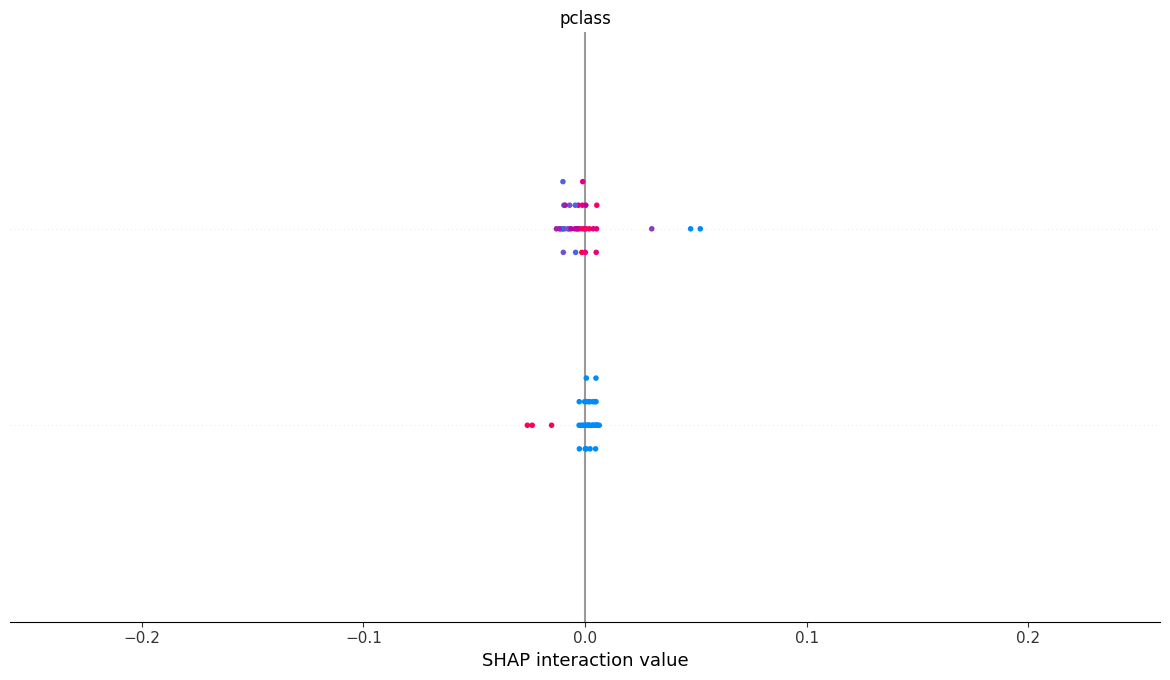

In [20]:
# Plot the SHAP summary 
shap.summary_plot(shap_values, X_test)

Therefore **Model Interpretation is a way of explaining results the way a doctor explains a diagnosis

## **Grid Search, Random Search, and Bayesian Optimization for Hyperparameter Tuning**

### **Grid Search**: Every possible combination

In [21]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators':[50, 100, 200],
    'max_depth':[3, 5, 10]
}

# Perform grid search 
grid_search = GridSearchCV(RandomForestClassifier(), param_grid,
                           cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [22]:
# Best parameters
print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'max_depth': 3, 'n_estimators': 50}


In [23]:
# Best model performance 
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Compute the accuracy score 
print("Tuned Model Accuracy: ", accuracy_score(y_test, y_pred))

Tuned Model Accuracy:  0.6756756756756757


### **Randomized Search**: Randomly selects some combinations

In [24]:
from sklearn.model_selection import RandomizedSearchCV

In [25]:
# Define hyperparameter grid  
param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth':[3, 5, 10, 20, None],
    'min_samples_split':[2, 5, 10]
}

In [26]:
# Perform random search
random_search = RandomizedSearchCV(RandomForestClassifier(), param_dist, 
                                  cv=5, n_iter=10, scoring="accuracy", random_state=40)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [3, 5, 10, 20, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300,
                                                         500]},
                   random_state=40, scoring='accuracy')

In [27]:
# Best parameters
print("Best parameters: ", random_search.best_params_)

Best parameters:  {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10}


In [28]:
# Evaluate best model
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Random Search Accuracy: ", accuracy_score(y_test, y_pred))

Random Search Accuracy:  0.7297297297297297


### **Bayesian Optimization**: `optuna`, `scikit-optimize`

In [29]:
import optuna
from sklearn.model_selection import cross_val_score

In [31]:
# Define objective function for optuna 
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    model = RandomForestClassifier(n_estimators = n_estimators, 
                                  max_depth = max_depth,
                                  min_samples_split = min_samples_split)

    return cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy").mean()

In [32]:
# Run optimization 
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 20)

[I 2025-03-26 12:32:45,699] A new study created in memory with name: no-name-86013768-b1c3-44de-a9c3-58738a29ef9a
[I 2025-03-26 12:32:51,548] Trial 0 finished with value: 0.696551724137931 and parameters: {'n_estimators': 258, 'max_depth': 14, 'min_samples_split': 9}. Best is trial 0 with value: 0.696551724137931.
[I 2025-03-26 12:32:52,923] Trial 1 finished with value: 0.6758620689655173 and parameters: {'n_estimators': 62, 'max_depth': 6, 'min_samples_split': 7}. Best is trial 0 with value: 0.696551724137931.
[I 2025-03-26 12:33:02,146] Trial 2 finished with value: 0.6827586206896552 and parameters: {'n_estimators': 422, 'max_depth': 11, 'min_samples_split': 4}. Best is trial 0 with value: 0.696551724137931.
[I 2025-03-26 12:33:04,858] Trial 3 finished with value: 0.6827586206896552 and parameters: {'n_estimators': 126, 'max_depth': 15, 'min_samples_split': 10}. Best is trial 0 with value: 0.696551724137931.
[I 2025-03-26 12:33:15,360] Trial 4 finished with value: 0.6689655172413793 

In [33]:
# Best parameters
print("Best parameters: ", study.best_params)

Best parameters:  {'n_estimators': 385, 'max_depth': 4, 'min_samples_split': 6}


In [34]:
# Evaluate the best model 
best_params = study.best_params
best_model = RandomForestClassifier(**best_params).fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Bayesian Optimization Accuracy: ", accuracy_score(y_test, y_pred))

Bayesian Optimization Accuracy:  0.7027027027027027


## **Model Interpretability Techniques**: SHAP and LIME

Imagine you visit a doctor, and they tell you:
"You have a 90% chance of having a disease."

Naturally, you'd ask: Why?

Similarly, in machine learning, when a model makes a prediction, we need to understand why it made that decision.

Two powerful techniques for this are:

1. SHAP
2. LIME

### SHAP (SHapley Additive ExPlanations)

What is SHAP? 

- Based on game theory, where each feature is like a player contributing to the final score (prediction).
- Shows how much each feature increases or decreases the prediction.
- Works well with tree-based models (Random Forest, XGBoost, LightGBM) and deep learning models.

<Figure size 640x480 with 0 Axes>

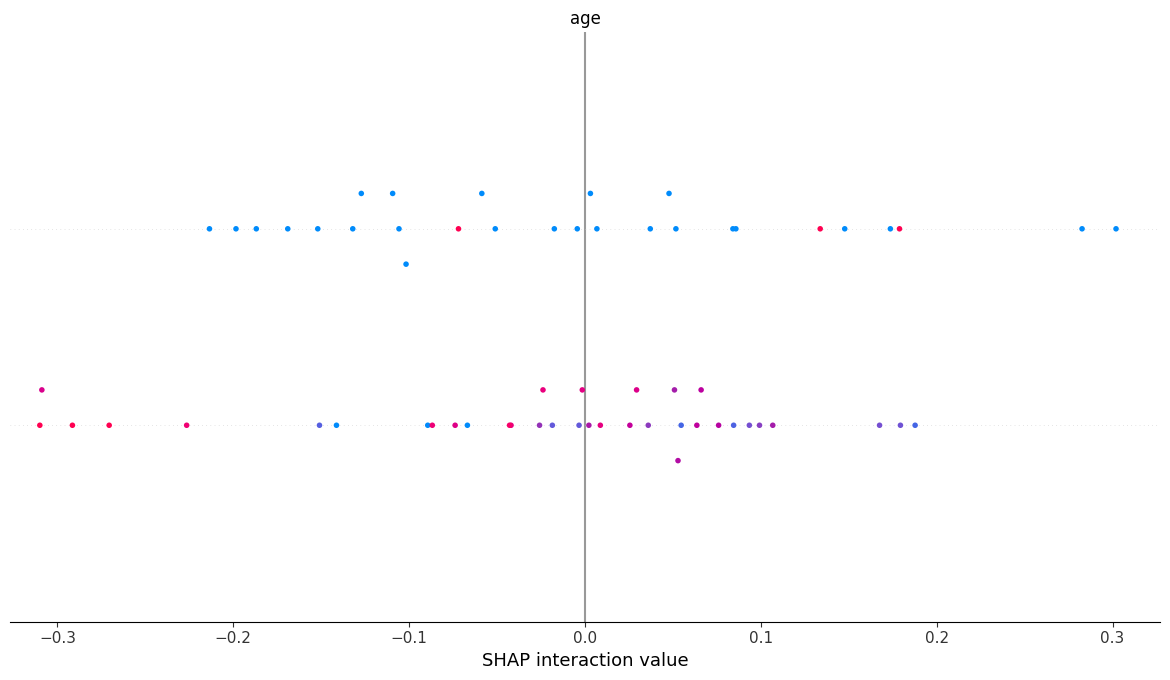

In [35]:
# Train a model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Explain model predictions using SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test)

### **LIME**: Local Interpretable Model-agnostic Explanations

What is LIME? (Just a breakdown)

- Works by slightly changing the input and seeing how the predictions change.
- Creates a simple interpretable model (like linear regression) to explain predictions of complex models.

Works with ANY machine learning model (agnostic).

In [36]:
import lime
import lime.lime_tabular
import numpy as np

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, 
                                                   feature_names=X_train.columns, 
                                                   class_names=['Not Survived', 'Survived'], 
                                                   mode='classification')

# Pick an instance to explain
i = np.random.randint(0, len(X_test))
exp = explainer.explain_instance(X_test.values[i], model.predict_proba)

# Show explanation
exp

/home/the-ape/CurrentProjects/whatsapp-business/DSAI-course/DSAI_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [37]:
from IPython import display

In [38]:
df_exp = pd.DataFrame(exp.as_list(), columns=["Feature", "Contribution"])
df_exp

,Feature,Contribution
0,age <= 25.00,0.163991
1,55.90 < fare <= 90.00,0.086576
2,sibsp <= 0.00,0.037880
3,pclass <= 1.00,-0.029622
4,parch <= 0.00,0.020434
